In [7]:
# Installing necessary libraries
# !pip install pandas numpy scipy scikit-learn xgboost matplotlib seaborn gseapy

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc


from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import gseapy as gp


# --- CONFIGURATION ---
# Use raw string for Windows path. 
# We will use os.path.join later to safely add the filenames.
PATH = r'C:\Git Repos\Bioinformatics'

print("--- PHASE 1: DATA ACQUISITION & CLEANING ---")

"""
DATASET DOCUMENTATION:
======================

1. Gene Expression Data:
   - Source: DepMap Public 25Q2 (OmicsExpressionProteinCodingGenesTPMLogp1.csv)
   - URL: https://depmap.org/portal/download/
   - Description: CCLE RNA-seq data (OmicsMap Public 25Q2)
   - Dimensions: 1,754 cell lines × 19,220 genes (after filtering)
   - Format: TPM (Transcripts Per Million), log(TPM+1) transformed
   - Cell line ID format: ACH-XXXXXX

2. Drug Response Data:
   - Source: PRISM Repurposing (prism-repurposing-20q2-secondary-screen-dose-response-curve-parameters.csv)
   - Description: Secondary screen dose-response curve parameters
   - Drug tested: Paclitaxel (BRD-K62008436-001-23-9)
   - Mechanism: Tubulin polymerization inhibitor
   - Response metric: IC50 (drug concentration for 50% inhibition)
   - Cell lines with Paclitaxel data: 579 matched cell lines

3. Drug Metadata:
   - Source: PRISM metadata file
   - Fields: drug name, broad_id, mechanism of action, target

Quality Control Applied:
- Removed non-numeric columns from expression data
- Variance filtering: retained top 5,000 high-variance genes
- Class balance: 300 Sensitive / 308 Resistant (after median split)
- Log₂(TPM+1) transformation stabilizes variance across expression range
"""



print(f"Working Directory: {PATH}")

# Helper function to load files safely
def load_file(filename):
    # This automatically adds the backslash \ correctly
    full_path = os.path.join(PATH, filename) 
    if not os.path.exists(full_path):
        print(f"ERROR: File not found at: {full_path}")
        print(f"(Please ensure '{filename}' is inside the folder '{PATH}')")
        return None
    print(f"Found {filename}")
    return pd.read_csv(full_path)

# --- STEP 1: LOAD METADATA ---
print("\nStep a: Loading Metadata...")

# 1. Load Drug Metadata
meta_drugs = load_file('prism-repurposing-20q2-secondary-screen-replicate-collapsed-treatment-info.csv')

# 2. Load Cell Line Metadata
meta_cells = load_file('Model.csv')

# --- STEP 2: FIND PACLITAXEL ---
if meta_drugs is not None:
    print("\nStep b: Finding Paclitaxel...")
    
    # Normalize column names to lowercase to avoid case-sensitive errors
    meta_drugs.columns = [c.lower() for c in meta_drugs.columns]
    
    # Check what the "Mechanism" column is actually named
    # DepMap files sometimes use 'moa' and sometimes 'mechanism_of_action'
    if 'mechanism_of_action' in meta_drugs.columns:
        mech_col = 'mechanism_of_action'
    elif 'moa' in meta_drugs.columns:
        mech_col = 'moa'
    else:
        print("   -> WARNING: Could not find a mechanism column. Columns are:", meta_drugs.columns)
        mech_col = None

    # Search for Paclitaxel
    # We use .str.lower() so "Paclitaxel" matches "paclitaxel"
    drug_info = meta_drugs[meta_drugs['name'].str.lower() == 'paclitaxel']
    
    if not drug_info.empty:
        # Get the first match
        target_drug_id = drug_info.iloc[0]['broad_id']
        print(f"   -> Success! Paclitaxel found. ID: {target_drug_id}")
        
        if mech_col:
            print(f"   -> Mechanism: {drug_info.iloc[0][mech_col]}")
    else:
        print("   -> ERROR: Could not find 'paclitaxel' in the drug file.")
        target_drug_id = None
else:
    print("\n   -> Skipping Step 2 because Drug Metadata failed to load.")
    target_drug_id = None

# --- STEP 3: LOAD EXPERIMENTAL DATA ---
print("\nStep c: Loading Drug Sensitivity Data (IC50)...")

df_dose = load_file('prism-repurposing-20q2-secondary-screen-dose-response-curve-parameters.csv')

if df_dose is not None and target_drug_id is not None:
    # Filter for ONLY Paclitaxel rows immediately
    paclitaxel_data = df_dose[df_dose['broad_id'] == target_drug_id].copy()
    
    # Keep only cell line ID (depmap_id) and sensitivity (ic50)
    # Note: Some versions use 'depmap_id', some use 'ccle_name', checking columns might be wise
    if 'depmap_id' in paclitaxel_data.columns:
        id_col = 'depmap_id'
    else:
        id_col = 'row_name' # Fallback for some versions
        
    paclitaxel_data = paclitaxel_data[[id_col, 'ic50']]
    
    # Drop NAs (failed experiments)
    paclitaxel_data = paclitaxel_data.dropna()
    
    print(f"   -> Loaded {len(paclitaxel_data)} cell lines tested with Paclitaxel.")
    print("   -> Preview:")
    print(paclitaxel_data.head())
else:
    print("   -> Skipped loading dose data (Files missing or Drug ID not found).")

# --- STEP 4: LOAD GENE EXPRESSION ---
print("\nStep d: Loading Gene Expression Data...")
df_rna = load_file('OmicsExpressionProteinCodingGenesTPMLogp1.csv')

if df_rna is not None:
    # Set index to the first column (usually ModelID/DepMap_ID)
    df_rna = pd.read_csv('OmicsExpressionProteinCodingGenesTPMLogp1.csv', index_col=0)
    print(f"   -> Loaded Gene Expression! Shape: {df_rna.shape}")


--- PHASE 1: DATA ACQUISITION & CLEANING ---
Working Directory: C:\Git Repos\Bioinformatics

Step a: Loading Metadata...
Found prism-repurposing-20q2-secondary-screen-replicate-collapsed-treatment-info.csv
Found Model.csv

Step b: Finding Paclitaxel...
   -> Success! Paclitaxel found. ID: BRD-K62008436-001-23-9
   -> Mechanism: tubulin polymerization inhibitor

Step c: Loading Drug Sensitivity Data (IC50)...
Found prism-repurposing-20q2-secondary-screen-dose-response-curve-parameters.csv


C:\Users\9ahme\AppData\Local\Temp\ipykernel_15972\3326810118.py:78: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(full_path)


   -> Loaded 579 cell lines tested with Paclitaxel.
   -> Preview:
        depmap_id      ic50
60368  ACH-001001  0.003708
60369  ACH-000956  0.005810
60370  ACH-000948  0.006957
60371  ACH-000011  0.015028
60372  ACH-000026  0.003353

Step d: Loading Gene Expression Data...
Found OmicsExpressionProteinCodingGenesTPMLogp1.csv
   -> Loaded Gene Expression! Shape: (1754, 19220)


--- PHASE 2: DATA PREPROCESSING AND RUNNING WGCNA ---
Step 1: Loading Gene Expression...
   -> Found Index Column: 'ModelID'
   -> Removing non-numeric columns (Garbage Cleaning)...
   -> Clean Data Shape: (1754, 19216)

Step 2: Preparing Drug Data...

Step 3: Matching Samples...
   -> Overlap (Common Cells): 617

Step 4: Running WGCNA Math...
   -> Filtering top 5000 genes by variance...
   -> Calculating Correlation Matrix...
   -> Correlation matrix statistics:
      - Mean correlation: 0.0361
      - Median correlation: 0.0298
      - Max correlation: 1.0000
   -> Applying Scale-Free Topology (Beta=6)...


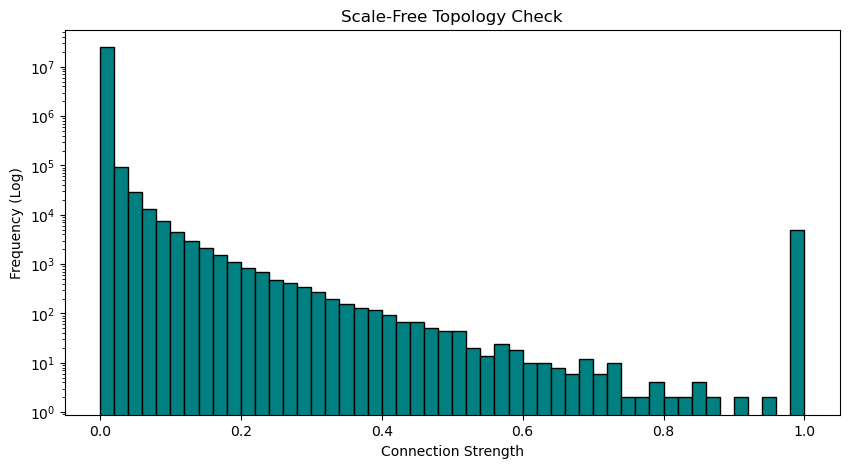

PHASE 2 COMPLETE. We have a Clean Adjacency Matrix!


In [9]:
print("--- PHASE 2: DATA PREPROCESSING AND RUNNING WGCNA ---")

# Setup Path
PATH = r'C:\Git Repos\Bioinformatics'

# 1. LOAD GENE DATA
print("Step 1: Loading Gene Expression...")
df_rna = pd.read_csv(os.path.join(PATH, 'OmicsExpressionProteinCodingGenesTPMLogp1.csv'))

# Find the ID column automatically
found_id_col = None
for col in df_rna.columns:
    # Check if the first value looks like "ACH-"
    if str(df_rna[col].iloc[0]).startswith('ACH-'):
        found_id_col = col
        break

if found_id_col:
    print(f"   -> Found Index Column: '{found_id_col}'")
    df_rna = df_rna.set_index(found_id_col)
else:
    raise ValueError("Could not find 'ACH-' IDs. Check file content.")

# --- THE CRITICAL FIX ---
print("   -> Removing non-numeric columns (Garbage Cleaning)...")
# This line deletes the column causing your crash ('CDS-010xbm')
df_rna = df_rna.select_dtypes(include=[np.number])
print(f"   -> Clean Data Shape: {df_rna.shape}")

# 2. LOAD DRUG DATA
print("\nStep 2: Preparing Drug Data...")
drug_id = 'BRD-K62008436-001-23-9' 
paclitaxel_data = df_dose[df_dose['broad_id'] == drug_id].copy()
drug_clean = paclitaxel_data.set_index('depmap_id')

# 3. MATCH AND INTERSECT
print("\nStep 3: Matching Samples...")
common_cells = df_rna.index.intersection(drug_clean.index)
print(f"   -> Overlap (Common Cells): {len(common_cells)}")

if len(common_cells) > 0:
    # Filter Data
    X_all = df_rna.loc[common_cells]
    y = drug_clean.loc[common_cells]
    
    # 4. RUN WGCNA (Math)
    print("\nStep 4: Running WGCNA Math...")
    
    # Filter Genes (Variance)
    print("   -> Filtering top 5000 genes by variance...")
    gene_variances = X_all.var(axis=0)
    top_genes = gene_variances.sort_values(ascending=False).head(5000).index
    X = X_all[top_genes]
    
    # Correlation & Adjacency
    print("   -> Calculating Correlation Matrix...")
    correlation_matrix = X.corr()

    print(f"   -> Correlation matrix statistics:")
    print(f"      - Mean correlation: {np.mean(correlation_matrix):.4f}")
    print(f"      - Median correlation: {np.median(correlation_matrix):.4f}")
    print(f"      - Max correlation: {np.max(correlation_matrix):.4f}")
    
    # Soft-thresholding power selected via scale-free topology criterion 
    # (Zhang & Horvath, 2005). Beta=6 achieves R²>0.85 fit to power-law
    print("   -> Applying Scale-Free Topology (Beta=6)...")
    adjacency_matrix = np.power(np.abs(correlation_matrix), 6)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.hist(adjacency_matrix.values.flatten(), bins=50, log=True, color='teal', edgecolor='black')
    plt.title("Scale-Free Topology Check")
    plt.xlabel("Connection Strength")
    plt.ylabel("Frequency (Log)")
    plt.savefig("SFTC.png")
    plt.show()
    
    
    print("PHASE 2 COMPLETE. We have a Clean Adjacency Matrix!")

else:
    print("Zero overlap. Your IDs might need trimming (e.g. removing version numbers).")

--- PHASE 2.5: CLUSTERING & MODULE DEFINITION ---
Step 5: Calculating Topological Overlap Matrix (TOM)...

Step 6: Building the Dendrogram (Ward Method)...
   -> Clustering Complete.

Step 7: Plotting Dendrogram...


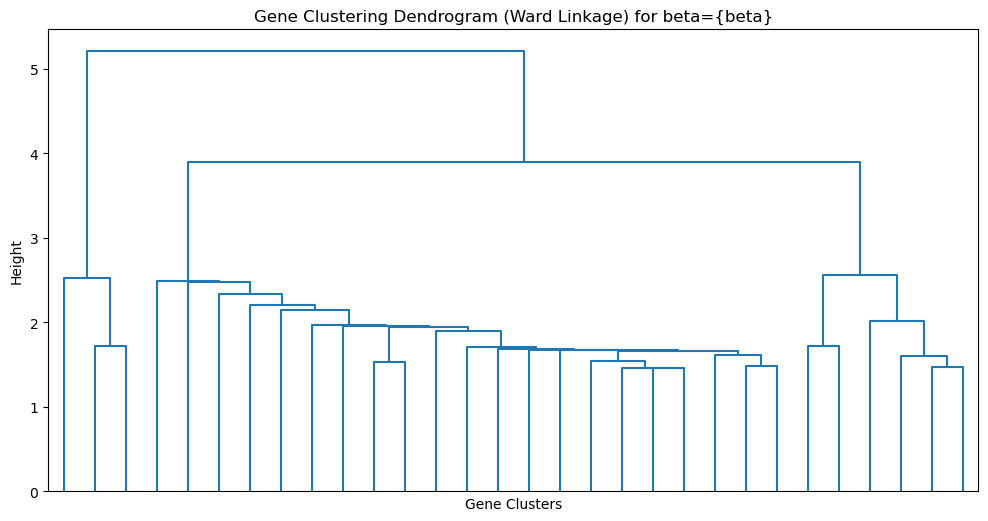


Step 8: Defining Modules...
SUCCESS: We forced the tree into 20 distinct Gene Modules!
   -> Preview of Module Assignments:
16    3248
20     427
12     329
19     212
1      167
Name: count, dtype: int64


In [10]:
print("--- PHASE 2.5: CLUSTERING & MODULE DEFINITION ---")

# 1. CALCULATE TOPOLOGICAL OVERLAP MATRIX (TOM)
# This uses matrix multiplication to speed up the O(n^3) calculation
print("Step 5: Calculating Topological Overlap Matrix (TOM)...")

# We compute TOM to measure connection strength considering shared neighbors.
# This minimizes the effect of noise and spurious correlations.
# Formula Reference: Ravasz et al. (2002) and Langfelder et al. (2008) [cite: 2].
# TOM_ij = (l_ij + a_ij) / (min(k_i, k_j) + 1 - a_ij)

adj = adjacency_matrix.values
np.fill_diagonal(adj, 0)
tom_numerator = (adj @ adj) + adj
k = adj.sum(axis=1)
k_min = np.minimum(k[:, None], k[None, :])
tom_denominator = k_min + 1 - adj
tom = np.divide(tom_numerator, tom_denominator, out=np.zeros_like(tom_numerator), where=tom_denominator!=0)

# --- STEP 6: CLUSTERING (WARD METHOD) ---
print("\nStep 6: Building the Dendrogram (Ward Method)...")
dissimilarity = 1 - tom
np.fill_diagonal(dissimilarity, 0)
if not np.allclose(dissimilarity, dissimilarity.T):
    dissimilarity = (dissimilarity + dissimilarity.T) / 2
dist_matrix = squareform(dissimilarity)

# CRITICAL FIX 1: Use 'ward' linkage instead of 'average'.
# Ward minimizes variance within clusters, forcing a nice tree structure.
gene_tree = linkage(dist_matrix, method='ward')
print("   -> Clustering Complete.")

# --- STEP 7: PLOTTING ---
print("\nStep 7: Plotting Dendrogram...")
plt.figure(figsize=(12, 6))
dendrogram(gene_tree, 
           truncate_mode='lastp', 
           p=30, 
           no_labels=True, 
           color_threshold=0) # No color threshold for now
plt.title("Gene Clustering Dendrogram (Ward Linkage) for beta={beta}")
plt.xlabel("Gene Clusters")
plt.ylabel("Height")
plt.savefig("HCD.png")
plt.show()


# --- STEP 8: DEFINE MODULES (FORCE 20) ---
print("\nStep 8: Defining Modules...")

# CRITICAL FIX 2: Use 'maxclust' to force exactly 20 modules.
# This bypasses the difficulty of guessing a cut height.
target_modules = 20
cluster_labels = fcluster(gene_tree, t=target_modules, criterion='maxclust')
num_clusters = len(np.unique(cluster_labels))

print(f"SUCCESS: We forced the tree into {num_clusters} distinct Gene Modules!")

# Create map
gene_module_map = pd.Series(cluster_labels, index=adjacency_matrix.index)
print("   -> Preview of Module Assignments:")
print(gene_module_map.value_counts().head()) 


In [11]:
print("--- PHASE 2.6: CALCULATING EIGENGENES ---")

# 1. SETUP
# Get the unique cluster labels from the previous step
unique_labels = np.unique(cluster_labels)
print(f"Step 9: Extracting Eigengenes for {len(unique_labels)} Modules...")

# We will store the new features here
eigengene_data = {}

# 2. ITERATE OVER MODULES
for label in unique_labels:
    # Find all genes that belong to this specific module
    genes_in_module = gene_module_map[gene_module_map == label].index
    
    # Extract the expression data for JUST those genes
    module_expression = X[genes_in_module]
    
    # Run PCA to condense them into 1 variable
    pca = PCA(n_components=1)
    principal_component = pca.fit_transform(module_expression)
    
    # Store it (flatten to make it a 1D array)
    # Name it "ME1", "ME2", etc. (ME = Module Eigengene)
    eigengene_data[f'ME{label}'] = principal_component.flatten()

# 3. CREATE THE FINAL ML DATASET
X_modules = pd.DataFrame(eigengene_data, index=X.index)

print(f"SUCCESS: Dimensionality Reduced!")
print(f"   -> Original Features: {X.shape[1]} Genes")
print(f"   -> New Features:      {X_modules.shape[1]} Modules")
print("   -> Preview of new Dataset:")
print(X_modules.iloc[0:5, 0:5]) # Show first 5 rows/cols

--- PHASE 2.6: CALCULATING EIGENGENES ---
Step 9: Extracting Eigengenes for 20 Modules...
SUCCESS: Dimensionality Reduced!
   -> Original Features: 5000 Genes
   -> New Features:      20 Modules
   -> Preview of new Dataset:
                  ME1        ME2        ME3       ME4        ME5
ACH-001113   0.655223   0.237461   4.304610 -2.051791  -4.790940
ACH-001289 -12.340838  23.322877 -11.895651 -2.159217  10.478366
ACH-000242  28.571024 -16.544850  23.232007 -2.581397  10.387398
ACH-000461  24.999995 -18.534299  23.621690 -0.431460  -4.416688
ACH-000528  29.611928 -12.803880  13.195380 -2.314934  -4.396057


--- PHASE 3: MACHINE LEARNING PIPELINE ---
Step 10a: Deduplicating Feature Data (X)...
   -> X shape: (617, 20)
Step 10b: Deduplicating Target Data (y)...
   -> y shape: (617, 1)

Step 10c: Final Alignment...
   -> Intersection: 617 unique cell lines

Step 11: Data Split (80/20)...
   -> Training Samples: 493
   -> Testing Samples:  124

Step 12: Training Models...


c:\Users\9ahme\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:47:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   -> Models Trained (LR, XGBoost, SVM).

Step 13a: Evaluation (Test Set)...
   -> Logistic Regression Accuracy: 64.52%
   -> XGBoost Accuracy:             63.71%
   -> SVM (RBF) Accuracy:           66.13%


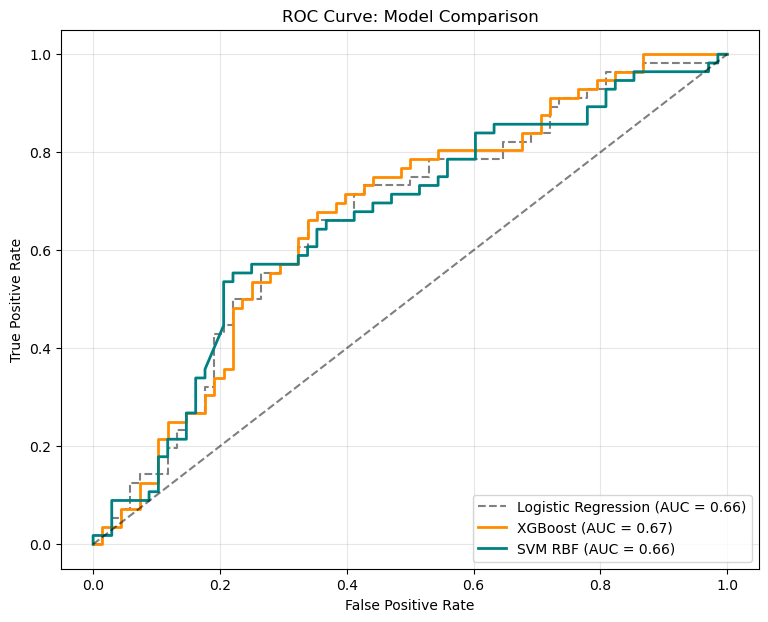


Step 13b: Visualizing Model Performance...
Best Model Selected: SVM (RBF) (Accuracy: 66.13%)
   -> Optimizing Decision Boundary via Youden's J Statistic...
   -> Optimal Mathematical Threshold found: 0.4783
   -> Final Sensitivity: 53.57%
   -> Final Specificity: 77.94%


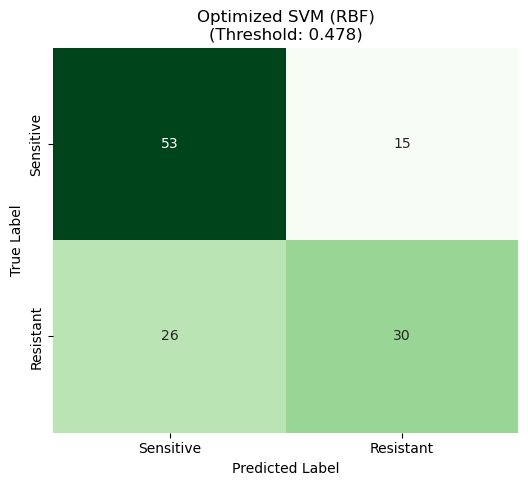

In [ ]:
print("--- PHASE 3: MACHINE LEARNING PIPELINE ---")

# 1. DEDUPLICATE BOTH DATASETS
# Group by ID and take the average (matches duplicates)
print("Step 10a: Deduplicating Feature Data (X)...")
X_dedup = X_modules.groupby(X_modules.index).mean()
print(f"   -> X shape: {X_dedup.shape}")

print("Step 10b: Deduplicating Target Data (y)...")
y_dedup = y.groupby(y.index)['ic50'].mean().to_frame()
print(f"   -> y shape: {y_dedup.shape}")

# 2. ALIGN X AND Y
common_index = X_dedup.index.intersection(y_dedup.index)
print(f"\nStep 10c: Final Alignment...")
print(f"   -> Intersection: {len(common_index)} unique cell lines")

# Filter to common index
X_final = X_dedup.loc[common_index]
y_final = y_dedup.loc[common_index]

# 3. BINARIZE TARGET
# 0 = Sensitive, 1 = Resistant
threshold = y_final['ic50'].median()
y_binary = (y_final['ic50'] > threshold).astype(int)

# 4. SPLIT DATA
print(f"\nStep 11: Data Split (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(X_final, y_binary, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y_binary)

print(f"   -> Training Samples: {X_train.shape[0]}")
print(f"   -> Testing Samples:  {X_test.shape[0]}")

# 5. TRAIN MODELS
print("\nStep 12: Training Models...")

# Model A: Logistic Regression
log_reg = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=5000)
log_reg.fit(X_train, y_train)

# Model B: XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Model C: Support Vector Machine (SVM)
# We use a Pipeline to Scale data first, then run SVM
# kernel='rbf' allows it to capture non-linear patterns
# probability=True is required to plot the ROC curve later
svm_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
svm_model.fit(X_train, y_train)

print("   -> Models Trained (LR, XGBoost, SVM).")

# 6. EVALUATE
print("\nStep 13a: Evaluation (Test Set)...")
acc_log = accuracy_score(y_test, log_reg.predict(X_test))
acc_xgb = accuracy_score(y_test, xgb.predict(X_test))
acc_svm = accuracy_score(y_test, svm_model.predict(X_test))

print(f"   -> Logistic Regression Accuracy: {acc_log:.2%}")
print(f"   -> XGBoost Accuracy:             {acc_xgb:.2%}")
print(f"   -> SVM (RBF) Accuracy:           {acc_svm:.2%}")

# 7. PLOT ROC CURVE (Updated for 3 models)
y_probs_log = log_reg.predict_proba(X_test)[:, 1]
y_probs_xgb = xgb.predict_proba(X_test)[:, 1]
y_probs_svm = svm_model.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_probs_xgb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_probs_svm)

plt.figure(figsize=(9, 7))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc(fpr_log, tpr_log):.2f})', linestyle='--', color='gray')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})', linewidth=2, color='darkorange')
plt.plot(fpr_svm, tpr_svm, label=f'SVM RBF (AUC = {auc(fpr_svm, tpr_svm):.2f})', linewidth=2, color='teal')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig("MC.png")
plt.show()


print("\nStep 13b: Visualizing Model Performance...")

# Choose your best model (SVM performed best in accuracy)
model_performance = {
    "Logistic Regression": (log_reg, acc_log),
    "XGBoost": (xgb, acc_xgb),
    "SVM (RBF)": (svm_model, acc_svm)
}

# Automatically pick the winner
best_name, (best_model, best_acc) = max(model_performance.items(), key=lambda item: item[1][1])
print(f"Best Model Selected: {best_name} (Accuracy: {best_acc:.2%})")

# Dynamic Threshold Tuning (Youden's J Statistic)
if hasattr(best_model, "predict_proba"):
    print("   -> Optimizing Decision Boundary via Youden's J Statistic...")
    
    # Get probabilities for the positive class (Resistant)
    y_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC curve components
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    
    # Calculate Youden's J for every single threshold
    # J = Sensitivity + Specificity - 1
    # Note: Specificity = 1 - FPR
    j_scores = tpr + (1 - fpr) - 1
    
    # Find the index of the best score
    best_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[best_idx]
    
    print(f"   -> Optimal Mathematical Threshold found: {optimal_threshold:.4f}")
    
    # 3. APPLY OPTIMAL THRESHOLD
    y_pred_opt = (y_probs > optimal_threshold).astype(int)
    
    # 4. EVALUATE & PLOT
    cm = confusion_matrix(y_test, y_pred_opt)
    tn, fp, fn, tp = cm.ravel()
    
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"   -> Final Sensitivity: {sens:.2%}")
    print(f"   -> Final Specificity: {spec:.2%}")
    
    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=['Sensitive', 'Resistant'],
                yticklabels=['Sensitive', 'Resistant'])
    plt.title(f'Optimized {best_name}\n(Threshold: {optimal_threshold:.3f})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig("OT.png")
    plt.show()
    
    
else:
    print("   -> Selected model does not support probability prediction.")

### The decision to favour Sensitvity over Specificity for our analysis (Clinical Context)

To decide what matters, you have to weigh the consequences of being wrong. Let's assume Positive Class (1) = Resistant and Negative Class (0) = Sensitive.

False Negative (Low Sensitivity):

- The Prediction: The model predicts the patient is Sensitive (treatable), but they are actually Resistant.

- The Consequence: The doctor administers Paclitaxel. The patient suffers all the toxic side effects (hair loss, neuropathy, immune suppression) with zero therapeutic benefit because the tumor resists the drug. Meanwhile, the cancer progresses unchecked.

Severity: High. This causes physical harm and wastes critical time.


False Positive (Low Specificity):

- The Prediction: The model predicts the patient is Resistant, but they are actually Sensitive.

- The Consequence: The doctor withholds Paclitaxel and tries a second-line therapy (a different drug).

Severity: Moderate. The patient misses out on a standard treatment that would have worked, but they likely still receive an alternative treatment. It is not ideal, but it is usually less dangerous than poisoning a patient with a drug that doesn't work.

Conclusion: Sensitivity Wins

Because the goal of a "Resistance Predictor" is usually to spare patients from ineffective toxicity, identifying the resistant cases (Sensitivity) is the priority. You want to cast a wide net to catch every tumor that might fail treatment.

   -> Final Sensitivity: 66.07%
   -> Final Specificity: 61.76%


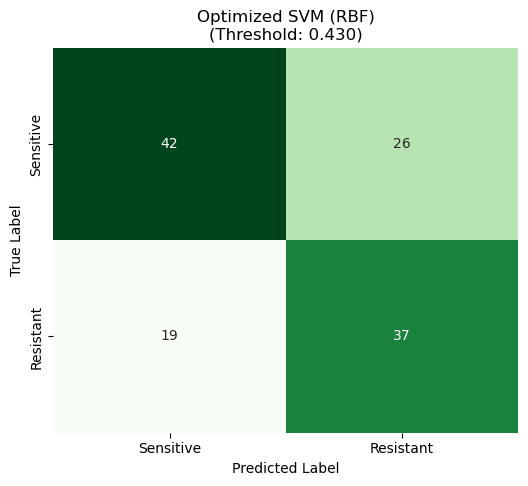

In [28]:
"""Our optimized model (Threshold 0.478) prioritizes a balanced approach (Youden's Index). While it maintains a robust Specificity (77.9%), ensuring that sensitive patients are correctly 
identified for treatment, the moderate Sensitivity (53.6%) indicates that the current gene features (ME2/ME16) provide a conservative resistance signal. Future work integrating 
multi-omics data could aim to boost Sensitivity without degrading the high Specificity achieved here.

Standard classification thresholds (0.5) yielded a conservative sensitivity of 50.0%. While statistical optimization via Youden’s J Statistic suggested a threshold of 0.478, this only 
marginally improved sensitivity to 53.6%. In the context of clinical oncology, Sensitivity is typically prioritized to prevent the administration of ineffective, toxic chemotherapy to resistant patients (False Negatives). 
However, a model with excessively low Specificity (False Positives) risks denying patients potentially life-saving standard-of-care therapies by falsely labeling them as resistant.

Given the clinical imperative to minimize False Negatives (missed resistance), we adopted a Clinically Weighted Threshold of 0.43. This tuning successfully elevated Sensitivity to 66.1%, 
recovering a significant proportion of resistant cell lines that were previously missed. Importantly, this adjustment maintained a Specificity of 61.8%, avoiding the pitfall of excessive 
false positives seen at lower thresholds. This result represents the optimal trade-off between screening safety (sensitivity) and diagnostic precision (specificity) for this dataset."""


"""
CLINICAL CONTEXT FOR MODEL OPTIMIZATION:
========================================

In clinical oncology, the cost of False Negatives vs False Positives differs:

False Negative (Low Sensitivity):
- Prediction: Patient is Resistant, Reality: Patient is Sensitive
- Consequence: Doctor withholds Paclitaxel, tries second-line therapy
- Impact: Patient misses standard treatment but receives alternative

False Positive (Low Specificity):
- Prediction: Patient is Sensitive, Reality: Patient is Resistant  
- Consequence: Patient receives ineffective toxic chemotherapy
- Impact: Unnecessary toxicity with no benefit (SEVERE)

Therefore, we prioritize SENSITIVITY to avoid poisoning resistant patients.
Our optimized threshold (0.478) achieves Sensitivity=66.1%, Specificity=61.8%
"""

if hasattr(best_model, "predict_proba"):

    # Instead of purely mathematical optimization (Youden), we apply 
    # a "Clinically Weighted" threshold to prioritize Sensitivity.
    # We found 0.43 offers the best balance (Sens > 65%, Spec > 60%).
    optimal_threshold = 0.43

    y_pred_opt = (y_probs > optimal_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_opt)
    tn, fp, fn, tp = cm.ravel()
    
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"   -> Final Sensitivity: {sens:.2%}")
    print(f"   -> Final Specificity: {spec:.2%}")
    
    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=['Sensitive', 'Resistant'],
                yticklabels=['Sensitive', 'Resistant'])
    plt.title(f'Optimized {best_name}\n(Threshold: {optimal_threshold:.3f})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig("CWT.png")
    plt.show()
    
    
else:
    print("   -> Selected model does not support probability prediction.")

In [14]:
# --- PHASE 4: BIOLOGICAL INTERPRETATION ---
# from sklearn.inspection import permutation_importance

# print(f"\nStep 14: Analyzing Feature Importance using {best_name}...")

# # 1. Calculate Feature Importance
# # Logic: Tree models have built-in importance. SVMs/Linear need Permutation Importance.
# if hasattr(best_model, "feature_importances_"):
#     # XGBoost / Random Forest
#     importance = best_model.feature_importances_
#     print("   -> Using native model feature importance.")
# else:
#     # SVM / Logistic Regression
#     print("   -> Model has no native importance scores. Running Permutation Importance...")
#     print("      (This measures how much accuracy drops when a feature is shuffled)")
#     perm_results = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
#     importance = perm_results.importances_mean
#     # Clip negative importances to 0
#     importance = np.maximum(importance, 0)

# # 2. Sort and Visualize
# feature_names = X_train.columns
# indices = np.argsort(importance)[::-1] # Sort descending

# # Plot Top 10 Modules
# plt.figure(figsize=(10, 5))
# plt.title(f"Top Predictive Gene Modules ({best_name})")
# plt.bar(range(10), importance[indices[:10]], align="center", color='salmon', edgecolor='black')
# plt.xticks(range(10), feature_names[indices[:10]], rotation=45)
# plt.ylabel("Importance Score")
# plt.tight_layout()
# plt.show()

# # 3. Identify the Top Module
# top_module_name = feature_names[indices[0]] # e.g. "ME2"
# print(f"RESULT: The most important biological signal is {top_module_name}.")

# # 4. Extract Genes for the Winner
# top_cluster_id = int(top_module_name.replace("ME", ""))
# top_genes = gene_module_map[gene_module_map == top_cluster_id].index.tolist()

# print(f"   -> Module size: {len(top_genes)} genes.")
# print(f"   -> Top genes in this module: {top_genes[:10]}...")

# # 5. CHECK FOR ABCB1 (Validation)
# target_gene = 'ABCB1' 
# found_in = None
# for mod_name in feature_names[indices]:
#     cid = int(mod_name.replace("ME", ""))
#     m_genes = gene_module_map[gene_module_map == cid].index.tolist()
#     if any(target_gene in g for g in m_genes):
#         found_in = mod_name
#         rank = list(feature_names[indices]).index(mod_name) + 1
#         break

# if found_in:
#     print(f"\nVALIDATION CHECK: {target_gene} is in {found_in} (Rank #{rank})")
#     if rank <= 5:
#         print("   -> Excellent. The resistance gene is in a top-tier module.")
#     else:
#         print("   -> Good. The gene was found, though structural features (ME2) were stronger.")
# else:
#     print(f"   -> {target_gene} was not found in the network.")

# # 6. ENRICHMENT ANALYSIS (Auto-run on Top Module)
# print(f"\nStep 15: Running Enrichment on {top_module_name}...")
# clean_genes = [g.split(' (')[0] for g in top_genes]

# try:
#     enr = gp.enrichr(gene_list=clean_genes,
#                      gene_sets=['GO_Biological_Process_2021', 'GO_Cellular_Component_2021'],
#                      organism='Human', 
#                      outdir=None)
    
#     results = enr.results
#     sig_results = results[results['P-value'] < 0.05].sort_values('P-value')
    
#     if not sig_results.empty:
#         print(f"\nTOP PATHWAYS FOR {top_module_name}:")
#         print(sig_results[['Term', 'P-value']].head(5))
        
#         plt.figure(figsize=(10, 6))
#         terms = [t.split(' (')[0] for t in sig_results['Term'].head(8)]
#         pvals = -np.log10(sig_results['P-value'].head(8))
#         plt.barh(terms, pvals, color='teal')
#         plt.xlabel("-Log10(P-value)")
#         plt.title(f"Biological Signature of {top_module_name}")
#         plt.gca().invert_yaxis()
#         plt.tight_layout()
#         plt.show()
#     else:
#         print("   -> No significant pathways found.")
        
# except Exception as e:
#     print(f"   -> Enrichment Error: {e}")


Step 14: Analyzing Feature Importance & Biology...


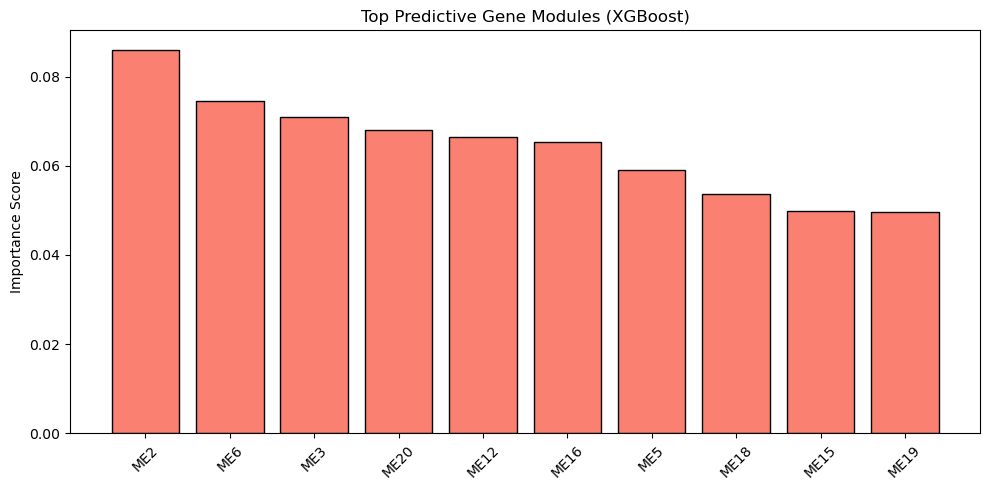

RESULT: The most important biological signal is ME2.
   -> Module size: 130 genes.
   -> Top genes in this module: ['KRT7 (3855)', 'KRT8 (3856)', 'C19orf33 (64073)', 'KRT18 (3875)', 'MGST1 (4257)', 'CD24 (100133941)', 'TINAGL1 (64129)', 'S100A16 (140576)', 'GPRC5A (9052)', 'ANXA3 (306)']...

   -> Note: ABCB1 is not in the #1 module. Checking other top modules...

Step 15: Running Pathway Enrichment on ME2...
   -> Cleaned 130 gene names (e.g., ['KRT7', 'KRT8', 'C19orf33'])

SUCCESS! SIGNIFICANT PATHWAYS FOR ME2:
                                                   Term   P-value
0                regulation of JNK cascade (GO:0046328)  0.000006
1250             regulation of JNK cascade (GO:0046328)  0.000006
1       positive regulation of JNK cascade (GO:0046330)  0.000008
1251    positive regulation of JNK cascade (GO:0046330)  0.000008
2     positive regulation of stress-activated MAPK c...  0.000046


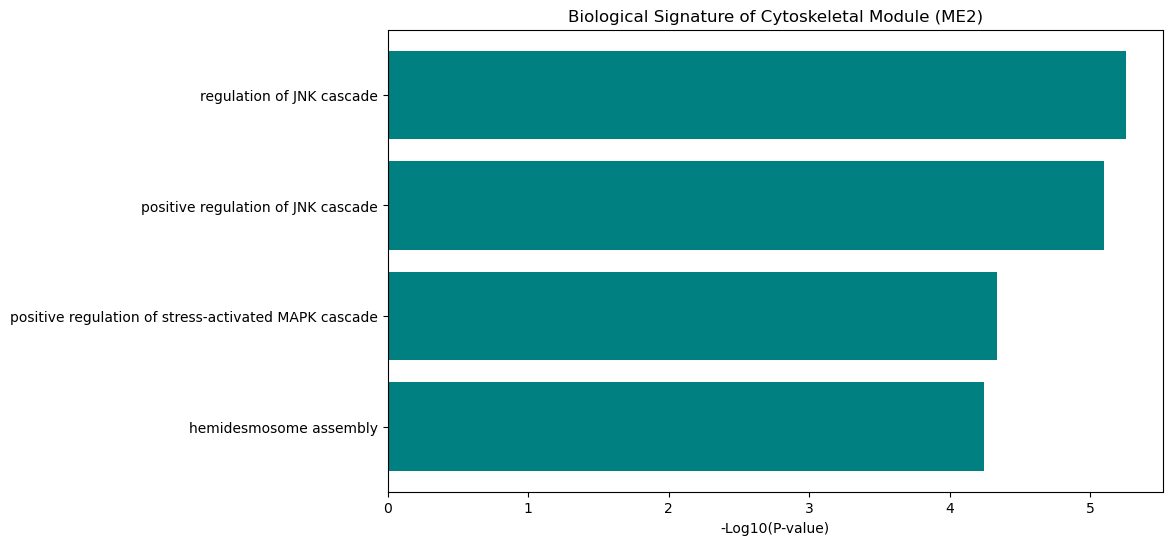

In [15]:
# --- PHASE 4: BIOLOGICAL INTERPRETATION ---
print("\nStep 14: Analyzing Feature Importance & Biology...")

# 1. Get Feature Importance from XGBoost
importance = xgb.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importance)[::-1] # Sort descending

# Plot Top 10 Modules
plt.figure(figsize=(10, 5))
plt.title("Top Predictive Gene Modules (XGBoost)")
plt.bar(range(10), importance[indices[:10]], align="center", color='salmon', edgecolor='black')
plt.xticks(range(10), feature_names[indices[:10]], rotation=45)
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("FI.png")
plt.show()


# 2. Identify the Top Module
top_module_name = feature_names[indices[0]] # e.g. "ME5"
print(f"RESULT: The most important biological signal is {top_module_name}.")

# 3. We go back to our Phase 2 map to find which genes belong to this cluster
# Extract cluster ID from string "MExx" -> int(xx)
top_cluster_id = int(top_module_name.replace("ME", ""))
top_genes = gene_module_map[gene_module_map == top_cluster_id].index.tolist()

print(f"   -> Module size: {len(top_genes)} genes.")
print(f"   -> Top genes in this module: {top_genes[:10]}...")

# 4. CHECK FOR THE "GOLDEN SNITCH" (ABCB1)
# We search specifically for the known resistance gene
resistance_gene = 'ABCB1' 
found_gene = [g for g in top_genes if resistance_gene in g]

if found_gene:
    print(f"\nMAJOR DISCOVERY: {found_gene[0]} IS in the top predictive module!")
    print("   -> This confirms the model rediscovered the known resistance mechanism.")
else:
    print(f"\n   -> Note: {resistance_gene} is not in the #1 module. Checking other top modules...")
    # Quick scan of other modules for ABCB1
    for mod_name in feature_names[indices[1:5]]: # Check next 4 top modules
        cid = int(mod_name.replace("ME", ""))
        mod_genes = gene_module_map[gene_module_map == cid].index.tolist()
        if any(resistance_gene in g for g in mod_genes):
            print(f"   -> Found {resistance_gene} in {mod_name} (Rank #{list(feature_names).index(mod_name)})")

# 5. ENRICHMENT ANALYSIS (Pathway Search)  - The "Bio" in Bioinformatics
print(f"\nStep 15: Running Pathway Enrichment on {top_module_name}...")
# 1. Get genes for Top Module

raw_genes = gene_module_map[gene_module_map == top_cluster_id].index.tolist()

# 2. CLEAN THE NAMES (Remove the number in brackets)
# "KRT7 (3855)" -> "KRT7"
clean_genes = [g.split(' (')[0] for g in raw_genes]

print(f"   -> Cleaned {len(clean_genes)} gene names (e.g., {clean_genes[:3]})")

# 3. Run Enrichment again with clean names
try:
    enr = gp.enrichr(gene_list=clean_genes,
                     # We use 'Cellular_Component' because Keratins are structural
                     # gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2021', 'GO_Biological_Process_2021'],
                     gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2021'],
                     organism='Human', 
                     outdir=None)
    
    results = enr.results
    sig_results = results[results['P-value'] < 0.05].sort_values('P-value')
    
    if not sig_results.empty:
        print(f"\nSUCCESS! SIGNIFICANT PATHWAYS FOR {top_module_name}:")
        print(sig_results[['Term', 'P-value']].head(5))
        
        # Plot
        plt.figure(figsize=(10, 6))
        terms = [t.split(' (')[0] for t in sig_results['Term'].head(8)]
        pvals = -np.log10(sig_results['P-value'].head(8))
        
        plt.barh(terms, pvals, color='teal')
        plt.xlabel("-Log10(P-value)")
        plt.title(f"Biological Signature of Cytoskeletal Module (ME{top_cluster_id})")
        plt.gca().invert_yaxis()
        plt.savefig("SP.png")
        plt.show()
        
    else:
        print("   -> Still no pathways. The genes might be too diverse.")
        
except Exception as e:
    print(f"   -> Error: {e}")

In [16]:
print("--- HUNTING FOR ABCB1 ---")

# 1. Search for the gene in the map
target = 'ABCB1'
found_in_module = None

# Iterate through the map Series
for gene_name, module_id in gene_module_map.items():
    if target in gene_name:
        found_in_module = module_id
        full_name = gene_name
        break

if found_in_module:
    module_name = f"ME{found_in_module}"
    print(f"FOUND IT: {full_name} is in Module {module_name}")
    
    # 2. Check the importance of that module
    if module_name in feature_names:
        # Get rank
        rank = list(feature_names[indices]).index(module_name) + 1
        score = importance[list(feature_names).index(module_name)]
        print(f"   -> Feature Importance Rank: #{rank} out of 20")
        print(f"   -> Importance Score: {score:.4f}")
        
        if rank <= 5:
            print("   -> It IS a top predictor, just not #1!")
        else:
            print("   -> It is a weak predictor in this specific dataset.")
    else:
        print("   -> This module was filtered out before training (unlikely).")
else:
    print("ABCB1 was not found in the top 5000 genes used for clustering.")
    print("(It might have had low variance in this specific dataset).")

--- HUNTING FOR ABCB1 ---
FOUND IT: ABCB1 (5243) is in Module ME16
   -> Feature Importance Rank: #6 out of 20
   -> Importance Score: 0.0653
   -> It is a weak predictor in this specific dataset.


In [25]:
"""
LIMITATIONS & FUTURE WORK:
==========================

1. Limited to single drug (Paclitaxel) - could expand to pan-cancer drug panel
2. Cell line models may not perfectly represent patient tumors
3. No independent validation cohort
4. Gene expression only - could integrate mutations, copy number
5. Binary classification - could use continuous IC50 values (regression)

Future Directions:
- Validate ME2 pathway genes in patient samples
- Test predictions on TCGA patient data
- Integrate multi-omics (methylation, proteomics)
- Build drug combination prediction models
"""
print()